# Cell 1: RapidRelief — Data Exploration
This notebook explores and visualizes the training datasets before model development.

Datasets:
- `training_data.csv` — 18 labeled fake messages (our own test set - may add 50-100+ more)
- `kaggle_disaster.csv` — 11,000 disaster tweets (binary labels)
- `crisislex_combined.csv` — 27,933 crisis tweets (relatedness labels)
- `crisisnlp_train.tsv` — CrisisNLP humanitarian categories (training split)

In [1]:
# ---------------------------------------------------------------------------
# Cell 2: All import tools needed for exploration
# ---------------------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from wordcloud import WordCloud
import sys
import os
import warnings
warnings.filterwarnings("ignore")

# Added backend to path so we can import preprocess.py
sys.path.append(os.path.abspath("../../backend"))
from utils.preprocess import preprocess_text

# Seting consistent plot style throughout notebook
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

print("All imports successful")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

All imports successful
pandas: 3.0.2
numpy: 2.4.4


In [2]:
# ---------------------------------------------------------------------------
# Cell 3: Loading all datasets 
# since each dataset has different columns and label formats, we will
# load each one separately first then explored one by one
# ---------------------------------------------------------------------------

# Paths relative to this notebook location (model_training/notebooks/)
DATA_PATH = "../../backend/data/"

# 1. Our own labeled fake messages
df_test = pd.read_csv(DATA_PATH + "training_data.csv")

# 2. Kaggle disaster tweets — binary labels (1=disaster, 0=not)
df_kaggle = pd.read_csv(DATA_PATH + "kaggle_disaster.csv")

# 3. CrisisLex combined — relatedness labels
df_crisislex = pd.read_csv(DATA_PATH + "crisislex_combined.csv")

# 4. CrisisNLP humanitarian categories — tab separated
df_crisisnlp = pd.read_csv(DATA_PATH + "crisisnlp_train.tsv", sep="\t")

print("Datasets loaded successfully!\n")
print(f"training_data.csv:      {len(df_test):>6} rows")
print(f"kaggle_disaster.csv:    {len(df_kaggle):>6} rows")
print(f"crisislex_combined.csv: {len(df_crisislex):>6} rows")
print(f"crisisnlp_train.tsv:    {len(df_crisisnlp):>6} rows")
print(f"\nTotal messages available: {len(df_test) + len(df_kaggle) + len(df_crisislex) + len(df_crisisnlp):,}")

Datasets loaded successfully!

training_data.csv:          18 rows
kaggle_disaster.csv:     11370 rows
crisislex_combined.csv:  27933 rows
crisisnlp_train.tsv:     61164 rows

Total messages available: 100,485


In [3]:
# ---------------------------------------------------------------------------
# Cell 4: Check columns, data types, and sample rows for each dataset
# ---------------------------------------------------------------------------

print("=" * 60)
print("1. training_data.csv")
print("=" * 60)
print(df_test.head())
print(f"\nColumns: {list(df_test.columns)}")

print("\n" + "=" * 60)
print("2. kaggle_disaster.csv")
print("=" * 60)
print(df_kaggle[["text", "target"]].head())
print(f"\nColumns: {list(df_kaggle.columns)}")

print("\n" + "=" * 60)
print("3. crisislex_combined.csv")
print("=" * 60)
print(df_crisislex.head())
print(f"\nColumns: {list(df_crisislex.columns)}")

print("\n" + "=" * 60)
print("4. crisisnlp_train.tsv")
print("=" * 60)
print(df_crisisnlp[["text", "class_label"]].head())
print(f"\nColumns: {list(df_crisisnlp.columns)}")

1. training_data.csv
                                                text urgency_level  \
0  Building collapsed, people trapped inside need...      Critical   
1  Multiple casualties reported at the intersecti...      Critical   
2  Wildfire spreading rapidly towards residential...      Critical   
3     Person having a heart attack at downtown plaza      Critical   
4  Flooding on highway 101 cars are being swept away      Critical   

  emergency_type  
0       Disaster  
1        Medical  
2  Environmental  
3        Medical  
4       Disaster  

Columns: ['text', 'urgency_level', 'emergency_type']

2. kaggle_disaster.csv
                                                text  target
0  Communal violence in Bhainsa, Telangana. "Ston...       1
1  Telangana: Section 144 has been imposed in Bha...       1
2  Arsonist sets cars ablaze at dealership https:...       1
3  Arsonist sets cars ablaze at dealership https:...       1
4  "Lord Jesus, your love brings freedom and pard...       0


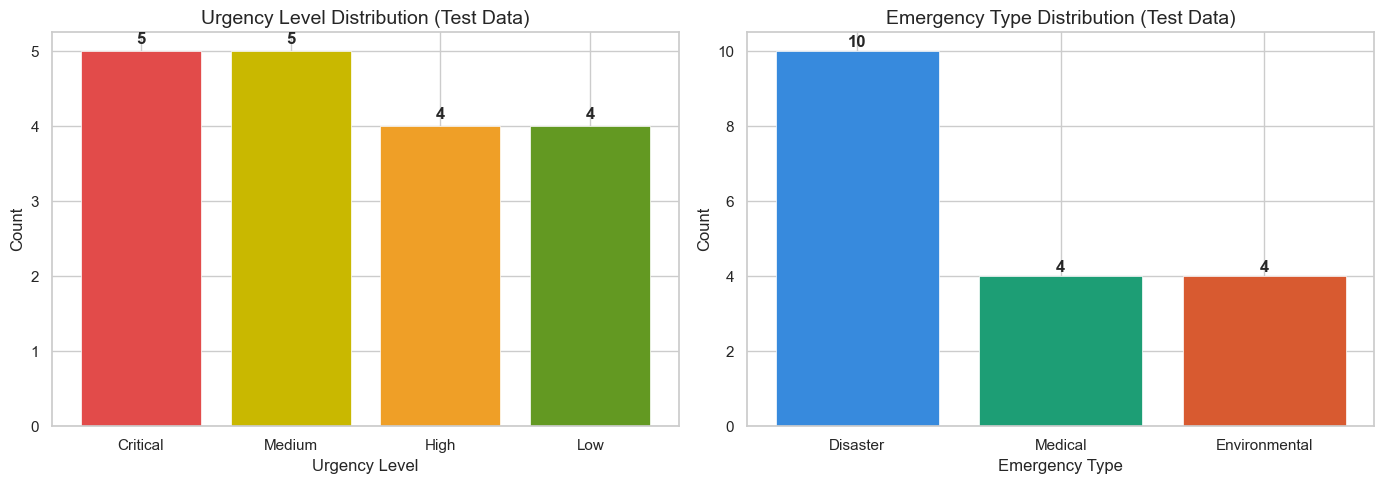

Chart saved.


In [4]:
# ---------------------------------------------------------------------------
# Cell 5 - Chart 1: Our training_data.csv label distributions
# This will showcase urgency level and emergency type breakdown
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Urgency level distribution
urgency_colors = {
    "Critical": "#E24B4A",
    "High":     "#EF9F27",
    "Medium":   "#c9b800",
    "Low":      "#639922"
}
urgency_counts = df_test["urgency_level"].value_counts()
axes[0].bar(
    urgency_counts.index,
    urgency_counts.values,
    color=[urgency_colors.get(u, "#888") for u in urgency_counts.index],
    edgecolor="white",
    linewidth=0.5
)
axes[0].set_title("Urgency Level Distribution (Test Data)")
axes[0].set_xlabel("Urgency Level")
axes[0].set_ylabel("Count")
for i, (label, count) in enumerate(urgency_counts.items()):
    axes[0].text(i, count + 0.1, str(count), ha="center", fontweight="bold")

# Emergency type distribution
type_counts = df_test["emergency_type"].value_counts()
axes[1].bar(
    type_counts.index,
    type_counts.values,
    color=["#378ADD", "#1D9E75", "#D85A30"],
    edgecolor="white",
    linewidth=0.5
)
axes[1].set_title("Emergency Type Distribution (Test Data)")
axes[1].set_xlabel("Emergency Type")
axes[1].set_ylabel("Count")
for i, (label, count) in enumerate(type_counts.items()):
    axes[1].text(i, count + 0.1, str(count), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../../backend/data/chart_test_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

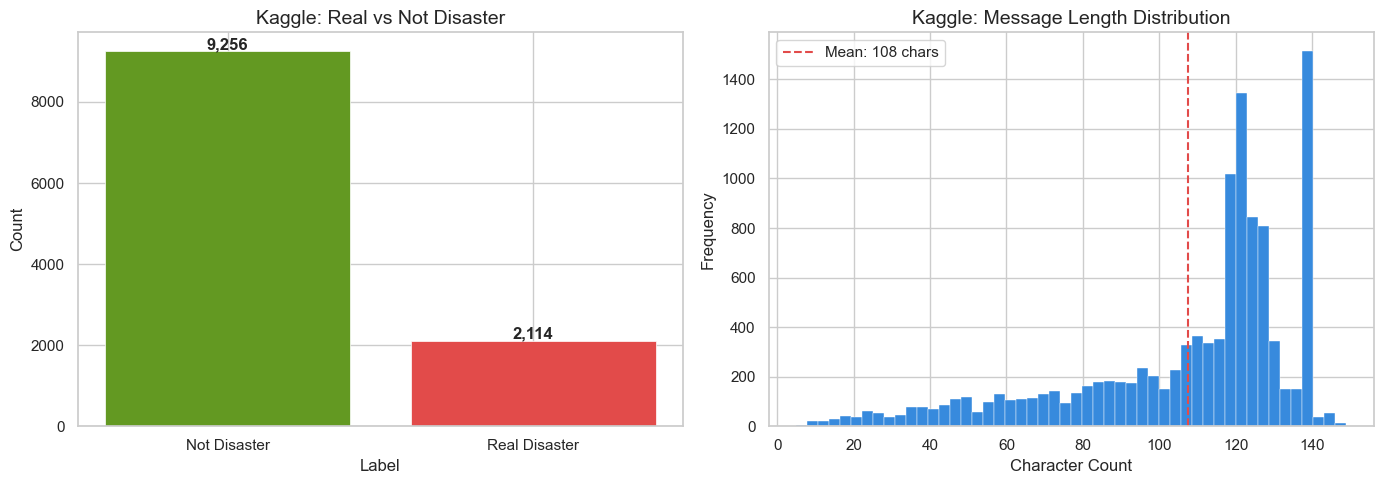

Kaggle dataset: {'Not Disaster': 9256, 'Real Disaster': 2114}


In [5]:
# ---------------------------------------------------------------------------
# Cell 6 - Chart 2: Kaggle disaster tweets label distribution
# indicates target: 1 = real disaster, 0 = not a disaster
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary label counts
label_map = {0: "Not Disaster", 1: "Real Disaster"}
kaggle_counts = df_kaggle["target"].value_counts().rename(index=label_map)

axes[0].bar(
    kaggle_counts.index,
    kaggle_counts.values,
    color=["#639922", "#E24B4A"],
    edgecolor="white",
    linewidth=0.5
)
axes[0].set_title("Kaggle: Real vs Not Disaster")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")
for i, (label, count) in enumerate(kaggle_counts.items()):
    axes[0].text(i, count + 50, f"{count:,}", ha="center", fontweight="bold")

# Message length distribution
df_kaggle["text_length"] = df_kaggle["text"].fillna("").apply(len)
axes[1].hist(
    df_kaggle["text_length"],
    bins=50,
    color="#378ADD",
    edgecolor="white",
    linewidth=0.3
)
axes[1].set_title("Kaggle: Message Length Distribution")
axes[1].set_xlabel("Character Count")
axes[1].set_ylabel("Frequency")
axes[1].axvline(
    df_kaggle["text_length"].mean(),
    color="#E24B4A",
    linestyle="--",
    label=f"Mean: {df_kaggle['text_length'].mean():.0f} chars"
)
axes[1].legend()

plt.tight_layout()
plt.savefig("../../backend/data/chart_kaggle_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Kaggle dataset: {kaggle_counts.to_dict()}")

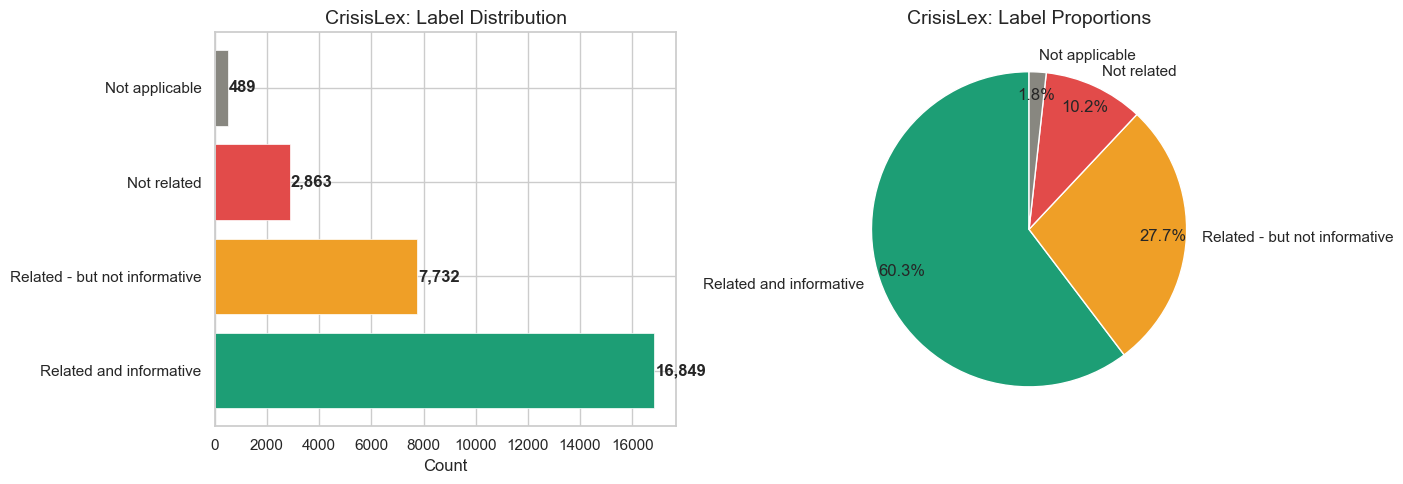

In [6]:
# ---------------------------------------------------------------------------
# Cell 7 - Chart 3: CrisisLex label distribution
# Labels: Related and informative, Related - but not informative, Not related, Not applicable
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

crisislex_counts = df_crisislex["label"].value_counts()

# Bar chart
colors = ["#1D9E75", "#EF9F27", "#E24B4A", "#888780"]
axes[0].barh(
    crisislex_counts.index,
    crisislex_counts.values,
    color=colors,
    edgecolor="white",
    linewidth=0.5
)
axes[0].set_title("CrisisLex: Label Distribution")
axes[0].set_xlabel("Count")
for i, (label, count) in enumerate(crisislex_counts.items()):
    axes[0].text(count + 50, i, f"{count:,}", va="center", fontweight="bold")

# Pie chart
axes[1].pie(
    crisislex_counts.values,
    labels=crisislex_counts.index,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.85
)
axes[1].set_title("CrisisLex: Label Proportions")

plt.tight_layout()
plt.savefig("../../backend/data/chart_crisislex_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

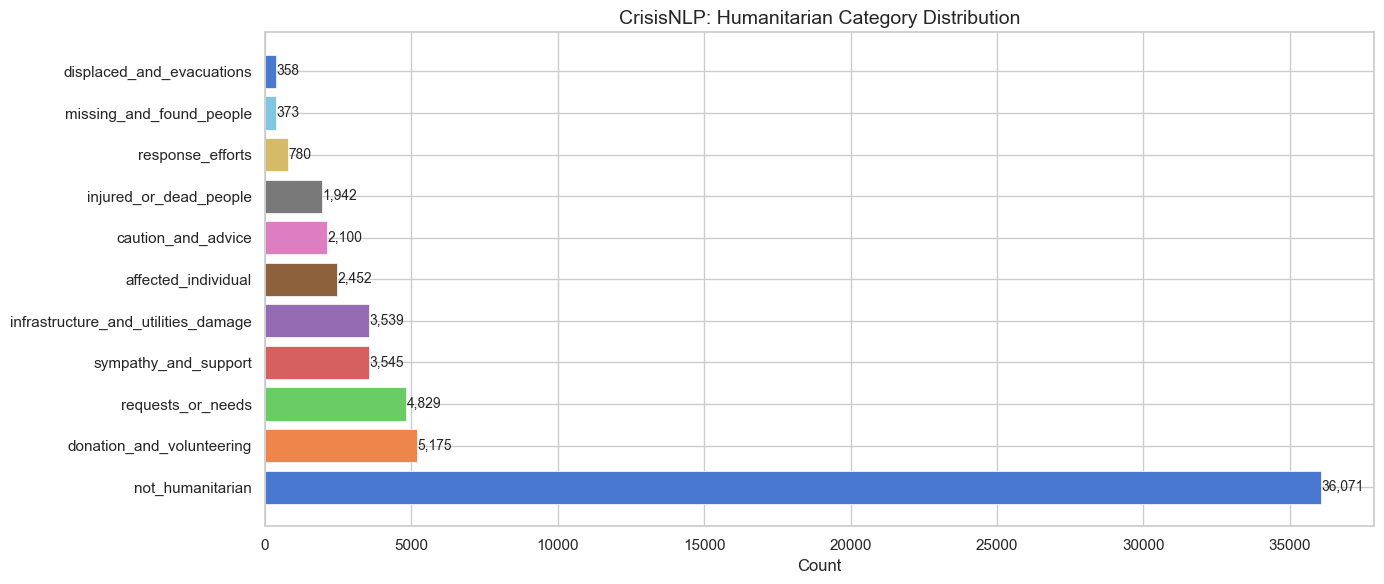


Total CrisisNLP training samples: 61,164


In [7]:
# ---------------------------------------------------------------------------
# Cell 8 - Chart 4: CrisisNLP humanitarian category distribution
# Shows what types of humanitarian information exist in the dataset
# ---------------------------------------------------------------------------

crisisnlp_counts = df_crisisnlp["class_label"].value_counts()

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(
    crisisnlp_counts.index,
    crisisnlp_counts.values,
    color=sns.color_palette("muted", len(crisisnlp_counts)),
    edgecolor="white",
    linewidth=0.5
)
ax.set_title("CrisisNLP: Humanitarian Category Distribution")
ax.set_xlabel("Count")
for i, (label, count) in enumerate(crisisnlp_counts.items()):
    ax.text(count + 20, i, f"{count:,}", va="center", fontsize=10)

plt.tight_layout()
plt.savefig("../../backend/data/chart_crisisnlp_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nTotal CrisisNLP training samples: {len(df_crisisnlp):,}")

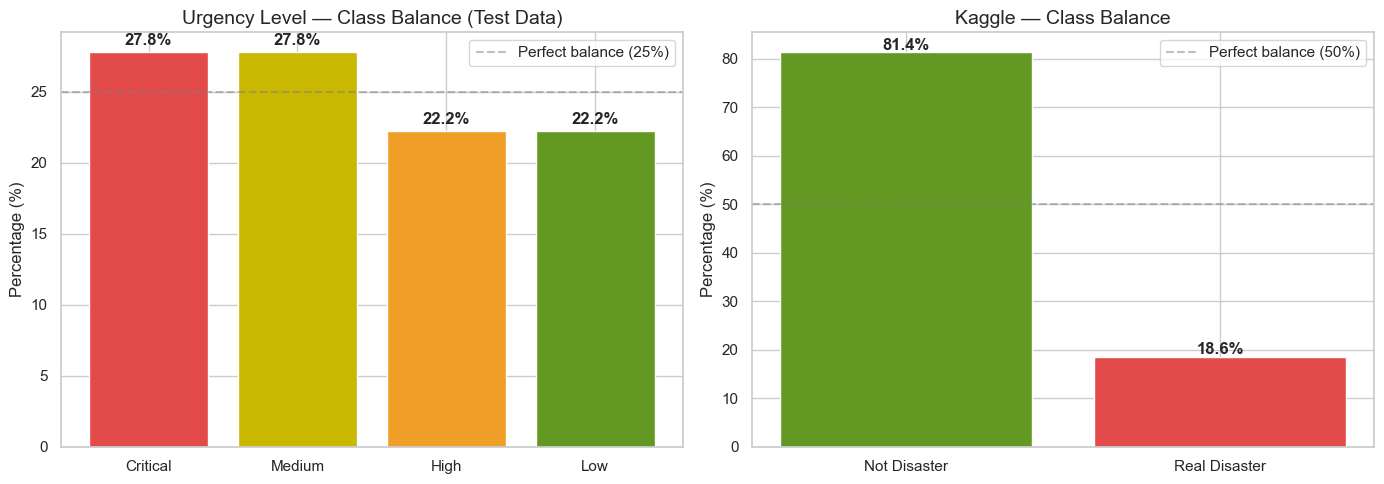


Class imbalance analysis complete.
Note: Imbalanced classes will need class weights during training.


In [8]:
# ---------------------------------------------------------------------------
# CCell 9 - hart 5: Class imbalance analysis
# This is critical — if Critical urgency is rare, models will underlearn it
# Important info to analyze before training to apply class weights
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Our test data imbalance
urgency_pct = df_test["urgency_level"].value_counts(normalize=True) * 100
axes[0].bar(
    urgency_pct.index,
    urgency_pct.values,
    color=[urgency_colors.get(u, "#888") for u in urgency_pct.index],
    edgecolor="white"
)
axes[0].set_title("Urgency Level — Class Balance (Test Data)")
axes[0].set_ylabel("Percentage (%)")
axes[0].axhline(25, color="gray", linestyle="--", alpha=0.5, label="Perfect balance (25%)")
axes[0].legend()
for i, (label, pct) in enumerate(urgency_pct.items()):
    axes[0].text(i, pct + 0.5, f"{pct:.1f}%", ha="center", fontweight="bold")

# Kaggle imbalance
kaggle_pct = df_kaggle["target"].value_counts(normalize=True) * 100
kaggle_pct.index = ["Not Disaster" if i == 0 else "Real Disaster" for i in kaggle_pct.index]
axes[1].bar(
    kaggle_pct.index,
    kaggle_pct.values,
    color=["#639922", "#E24B4A"],
    edgecolor="white"
)
axes[1].set_title("Kaggle — Class Balance")
axes[1].set_ylabel("Percentage (%)")
axes[1].axhline(50, color="gray", linestyle="--", alpha=0.5, label="Perfect balance (50%)")
axes[1].legend()
for i, (label, pct) in enumerate(kaggle_pct.items()):
    axes[1].text(i, pct + 0.5, f"{pct:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../../backend/data/chart_class_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nClass imbalance analysis complete.")
print("Note: Imbalanced classes will need class weights during training.")

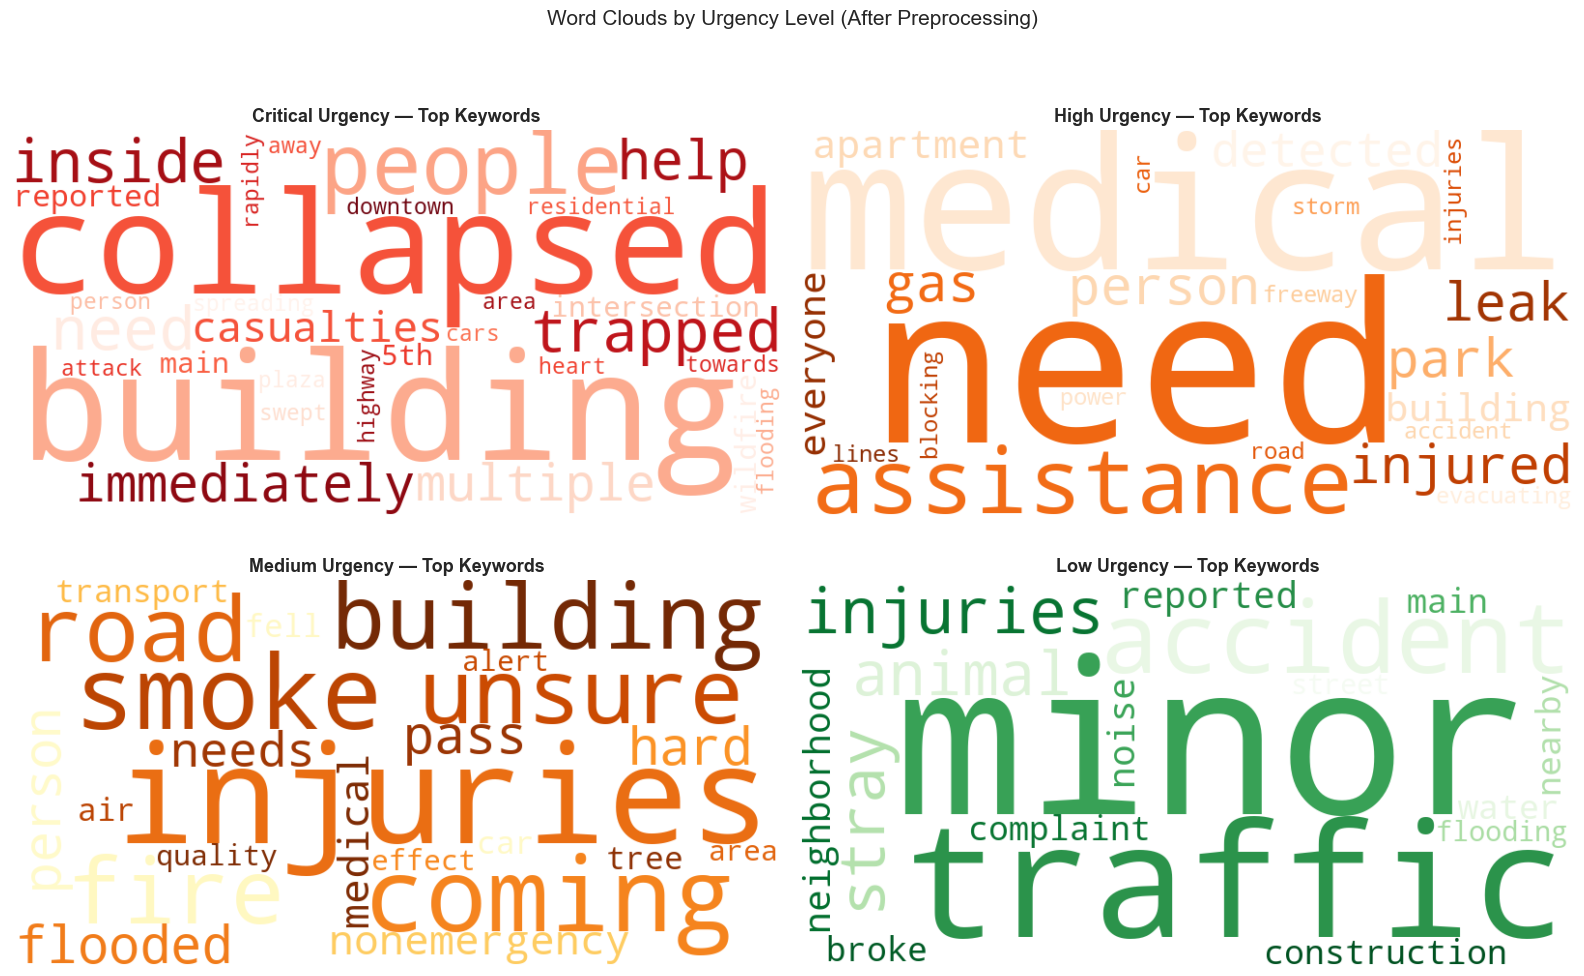

Word clouds generated using preprocess.py pipeline.


In [9]:
# ---------------------------------------------------------------------------
# Cell 10 - Chart 6: Word clouds per urgency level
# Shows most common words in Critical vs Low messages after preprocessing
# To verify preprocess.py is working and will give us insight into
# what language patterns distinguish urgency levels
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

urgency_levels = ["Critical", "High", "Medium", "Low"]
urgency_colors_wc = {
    "Critical": "Reds",
    "High":     "Oranges",
    "Medium":   "YlOrBr",
    "Low":      "Greens"
}

for i, level in enumerate(urgency_levels):
    # Filter messages for this urgency level
    subset = df_test[df_test["urgency_level"] == level]["text"]

    if len(subset) == 0:
        axes[i].set_title(f"{level} — No data")
        continue

    # Clean text using our preprocess pipeline
    cleaned = " ".join(subset.apply(preprocess_text))

    # Generate word cloud
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        colormap=urgency_colors_wc[level],
        max_words=50,
        collocations=False
    ).generate(cleaned)

    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].set_title(f"{level} Urgency — Top Keywords", fontsize=13, fontweight="bold")
    axes[i].axis("off")

plt.suptitle("Word Clouds by Urgency Level (After Preprocessing)", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("../../backend/data/chart_wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()
print("Word clouds generated using preprocess.py pipeline.")

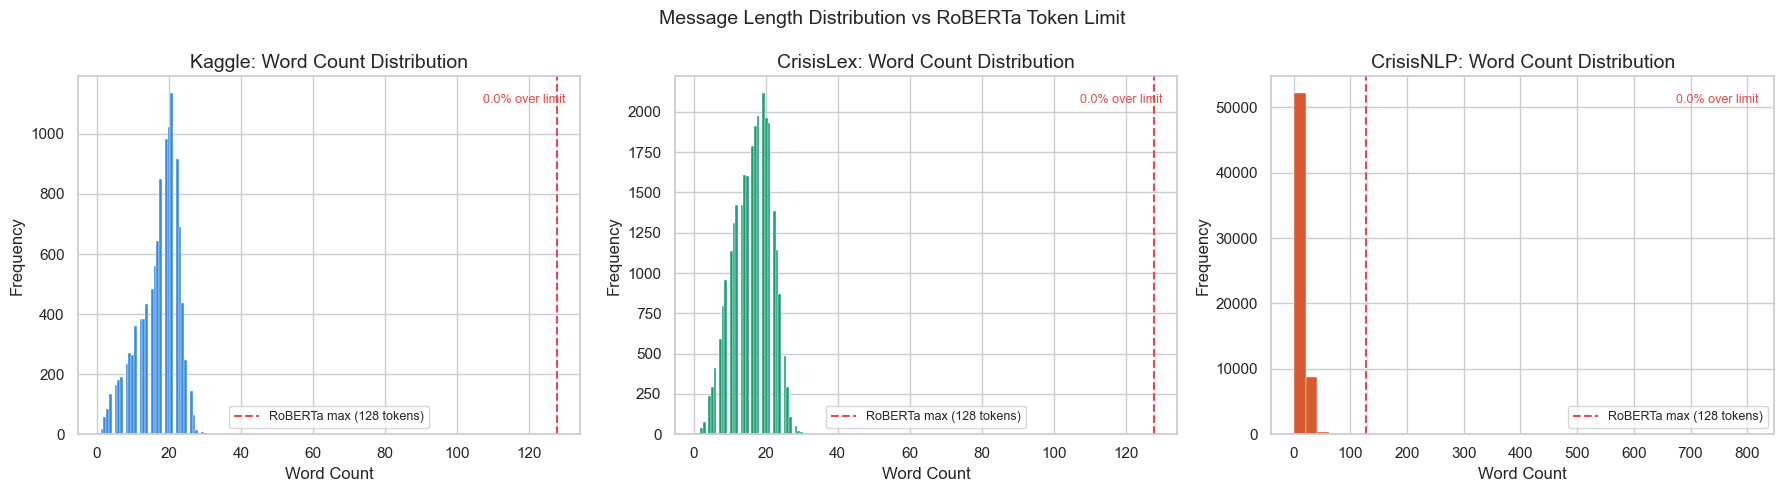

In [10]:
# ---------------------------------------------------------------------------
# Cell 11 - Chart 7: Message length distribution across all datasets
# RoBERTa has a max token limit of 128 — messages longer than this
# will be truncated. This chart shows how many messages might be affected.
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [
    (df_kaggle["text"].fillna(""), "Kaggle", "#378ADD"),
    (df_crisislex["text"].fillna(""), "CrisisLex", "#1D9E75"),
    (df_crisisnlp["text"].fillna(""), "CrisisNLP", "#D85A30"),
]

for ax, (texts, name, color) in zip(axes, datasets):
    lengths = texts.apply(lambda x: len(x.split()))  # word count
    ax.hist(lengths, bins=40, color=color, edgecolor="white", linewidth=0.3)
    ax.axvline(128, color="#E24B4A", linestyle="--", linewidth=1.5,
               label="RoBERTa max (128 tokens)")
    ax.set_title(f"{name}: Word Count Distribution")
    ax.set_xlabel("Word Count")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)

    # Percentage over 128 words
    over_limit = (lengths > 128).sum()
    pct_over = over_limit / len(lengths) * 100
    ax.text(0.97, 0.95, f"{pct_over:.1f}% over limit",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=9, color="#E24B4A")

plt.suptitle("Message Length Distribution vs RoBERTa Token Limit", fontsize=14)
plt.tight_layout()
plt.savefig("../../backend/data/chart_message_lengths.png", dpi=150, bbox_inches="tight")
plt.show()

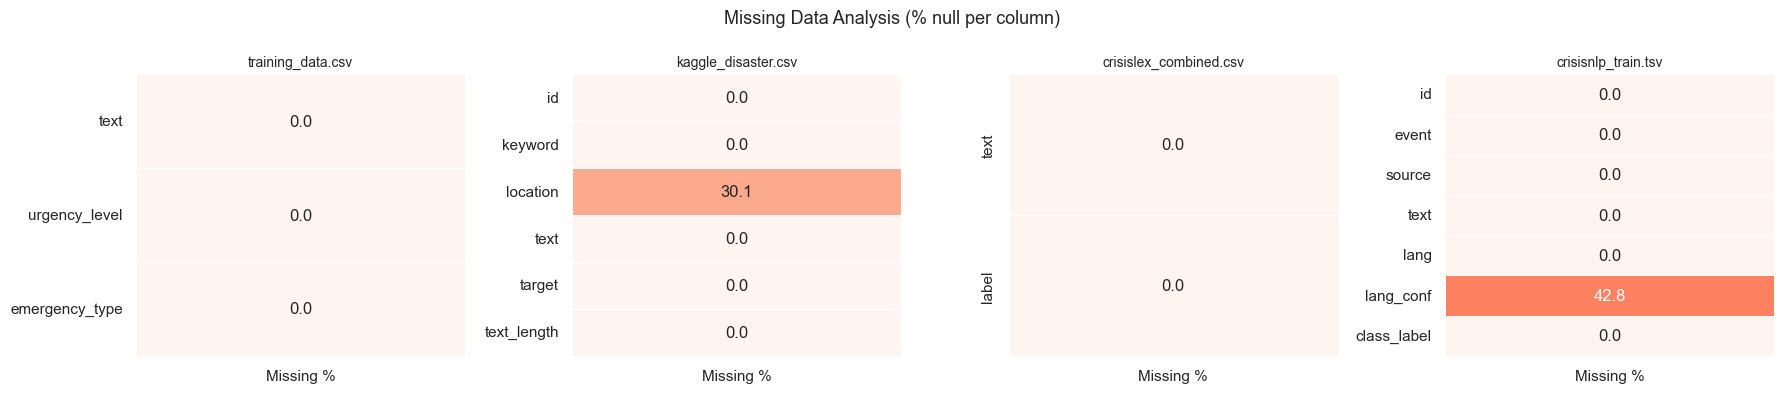

In [11]:
# ---------------------------------------------------------------------------
# Cell 12 - Chart 8: Missing data heatmap
# Shows which columns have null values across all datasets
# Important to know before training — nulls can cause crashes
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

datasets_info = [
    (df_test,       "training_data.csv"),
    (df_kaggle,     "kaggle_disaster.csv"),
    (df_crisislex,  "crisislex_combined.csv"),
    (df_crisisnlp,  "crisisnlp_train.tsv"),
]

for ax, (df, name) in zip(axes, datasets_info):
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(1)
    missing_df = pd.DataFrame({"Missing %": missing_pct})

    sns.heatmap(
        missing_df,
        ax=ax,
        annot=True,
        fmt=".1f",
        cmap="Reds",
        vmin=0,
        vmax=100,
        linewidths=0.5,
        cbar=False
    )
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("")

plt.suptitle("Missing Data Analysis (% null per column)", fontsize=13)
plt.tight_layout()
plt.savefig("../../backend/data/chart_missing_data.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 13 - Exploration Summary

| Dataset                | Rows         | Label Type     | Key Finding                            |
|------------------------|--------------|----------------|----------------------------------------|
| training_data.csv      | 18           | urgency + type | Balanced across 4 urgency levels       |
| kaggle_disaster.csv    | about 11,000 | binary         | Slight imbalance toward real disasters |
| crisislex_combined.csv | 27,933       | relatedness    | Majority are related and informative   |
| crisisnlp_train.tsv    | varies       | humanitarian   | not_humanitarian is the dominant class |

### Key Observations
- Since class imbalance exists in all datasets, we will apply **class weights** during training
- Most messages are under 128 words — RoBERTa truncation will affect very few samples
- Word clouds confirm preprocess.py is correctly cleaning emergency-related language
- Missing data is minimal in text columns — no imputation needed

### Next Steps
- Proceed to `model_training.ipynb` to train Logistic Regression, Random Forest, and RoBERTa